# Temporal and Spatial Context

The baseline XGBoost model trained in Chapter 3 treats every observation as an independent sample — there is no explicit link between the same spatial pixel across consecutive days. Two hypotheses are tested here to see whether richer context can improve predictive precision for `fwns`:

1. **Temporal context:** does providing the model with measurements from the same pixel on a prior day improve accuracy?
2. **Spatial context:** does providing measurements from neighbouring pixels help? *(planned for a later section)*

This notebook focuses entirely on the **temporal hypothesis**. We run a systematic lag sweep (1 to 30 days) across four carefully designed feature sets and track how R², RMSE and MAE evolve with increasing lag distance.

## 1. Setup

Load libraries, define the lag range and the four feature-set names used throughout the notebook. All downstream cells import variables defined here.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
import json
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option('display.max_columns', None)
np.random.seed(42)
SEED = 42

LAGS = list(range(1, 31))  # 1 to 30 days

# 4 feature set configurations
# A: current only
# B: current + previous features (all non-fwns lag cols)
# C: current + previous fwns ground truth only
# D: current + previous features + previous fwns ground truth
FEATURE_SET_NAMES = [
    'A: current only',
    'B: current + prev features',
    'C: current + prev fwns',
    'D: current + prev features + prev fwns',
]

## 2. Data Loading

Load all 726 daily Parquet files from `data/datasets/` (2017–2018, ~26.5 M rows). The entire dataset is sorted once by `(latitude_grid, longitude_grid, year, day_of_year)` so that every subsequent lag operation can rely on group-level `.shift()` without re-sorting.

In [2]:
# Load dataset and sort once — all lag experiments share this base
print("Loading dataset...")
df_raw = pd.read_parquet('data/datasets')
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")

print("Sorting by pixel and time...")
df_raw = df_raw.sort_values(
    ['latitude_grid', 'longitude_grid', 'year', 'day_of_year']
).reset_index(drop=True)

print("Done.")

Loading dataset...
Loaded: 26,482,762 rows x 52 cols
Sorting by pixel and time...
Done.


## 3. Feature Sets and Model Configuration

### 3.1 Feature Set Definitions

Four feature sets are evaluated across every lag experiment:

| Set | Contents | Rationale |
|-----|----------|-----------|
| **A** | Current-day features only | Replicates the baseline model from Chapter 3 — no temporal information |
| **B** | Current + previous features (all non-`fwns` lag columns) | Tests whether lagged observational and derived features add predictive value |
| **C** | Current + previous `fwns` ground truth | Tests pure autoregressive signal — how much does knowing yesterday's water fraction help? |
| **D** | Current + previous features + previous `fwns` | Full temporal context — combines both effects |

`BASELINE_FEATURES` is the same 24-feature set that achieved R²≈0.924 in Chapter 3. The HPO hyperparameters from `HPO_results/best_xgb_params.json` are reused unchanged so that any accuracy difference is attributable solely to the additional context features.

In [3]:
# Columns to include as "previous features" (everything except target fwns)
PREV_FEATURE_COLS = [
    'tbtoa19H', 'tbtoa19V', 'tbtoa37H', 'tbtoa37V',
    'emiss19H_de_lannoy', 'emiss19V_de_lannoy', 'emiss37H_de_lannoy', 'emiss37V_de_lannoy',
    'Tmn', 'PWV', 'VPD', 'vsm', 'VOD', 'surtep_ERA5',
    'fwns_calculated',
]

# Current-day baseline features (no lag)
BASELINE_FEATURES = [
    'latitude_grid',
    'Tmn', 'PWV', 'VOD', 'vsm', 'VPD', 'surtep_ERA5',
    'tran19V', 'tran37V', 'tbup19V', 'tbup37V',
    'emiss19H_de_lannoy', 'emiss19V_de_lannoy',
    'emiss37H_de_lannoy', 'emiss37V_de_lannoy',
    'tbtoa19H', 'tbtoa19V', 'tbtoa37H', 'tbtoa37V',
    'ref_land_emis_de_lannoy_K_h', 'ref_land_emis_de_lannoy_K_v',
    'denominator',
    'fwns_calculated',
    'doy_sin',
]

# Load HPO params
with open('HPO_results/best_xgb_params.json') as f:
    best_params = json.load(f)

print(f"Baseline features: {len(BASELINE_FEATURES)}")
print(f"Previous feature columns to lag: {len(PREV_FEATURE_COLS)}")
print(f"Lag range: {LAGS[0]}..{LAGS[-1]} days")

Baseline features: 24
Previous feature columns to lag: 15
Lag range: 1..30 days


## 4. Lag Dataset Construction

### 4.1 `build_lag_dataset` — per-lag filtering logic

For a given lag *L*, `build_lag_dataset` produces a dataset where every row contains both the current-day observation and features from **exactly** *L* calendar days earlier at the same pixel.

The function uses a **merge-based approach**: it builds a lookup table from `df_sorted`, shifts each row's `day_of_year` forward by *L*, renames all lagged columns to `*_lag`, then inner-joins it back onto `df_sorted` on `(latitude_grid, longitude_grid, year, day_of_year)`. A row survives only if the original dataset contains an observation for that pixel exactly *L* calendar days earlier in the same year.

This is correct even when satellite passes are irregular. A shift-based approach (`.shift(lag)`) is positional — it steps back *L* rows in the sorted group — and gives wrong results whenever there are observation gaps. For example, with observations on days [1, 2, 3, 5, 10] and lag=5, `shift(5)` from day 10 lands on day 3 (the 5th-prior *row*), discarding the valid (10, 5) pair. The merge approach finds day 5 directly via the join key and retains the pair correctly.

Year boundaries are enforced automatically: `year` is part of the join key, so a prior observation from year 2017 can never be paired with a current observation from year 2018.

In [8]:
def build_lag_dataset(df_sorted, lag):
    """
    For a given lag L, build a dataset where each row contains:
      - current-day features
      - lagged features from exactly L calendar days prior for the same pixel
    Only rows that have an observation exactly L calendar days prior (same year)
    are kept. Year boundaries are not crossed.

    Uses a merge-based approach rather than positional shift(), so irregular
    observation gaps do not cause valid (current, prior) pairs to be discarded.
    For example, with lag=5 and observations on days [1,2,3,5,10], the pair
    (current=day 10, prior=day 5) is correctly retained: shift(5) from day 10
    would have landed on day 3 (the 5th-prior row), triggering a false discard.
    """
    n_before = len(df_sorted)

    # Build the prior-day lookup table.
    # Adding lag to day_of_year shifts each prior observation's key forward by L,
    # so that joining on day_of_year aligns it with the current observation L days later.
    prior = df_sorted[
        ['latitude_grid', 'longitude_grid', 'year', 'day_of_year']
        + PREV_FEATURE_COLS + ['fwns']
    ].copy()
    prior['day_of_year'] = prior['day_of_year'] + lag
    prior = prior.rename(columns={c: f'{c}_lag' for c in PREV_FEATURE_COLS + ['fwns']})

    # Inner join: keeps only rows where an observation exactly lag calendar days
    # earlier exists in the same year. The join on (lat, lon, year, day_of_year)
    # naturally enforces the same-year constraint — no explicit year-boundary check needed.
    df = df_sorted.merge(
        prior,
        on=['latitude_grid', 'longitude_grid', 'year', 'day_of_year'],
        how='inner',
    )

    n_after = len(df)
    print(f"  lag={lag}: {n_before:,} -> {n_after:,} rows retained "
          f"({100 * n_after / n_before:.1f}%)", end='')

    return df

print("build_lag_dataset() defined.")

build_lag_dataset() defined.


### 4.2 Training and evaluation helpers

`get_feature_sets` assembles the four feature lists (A–D) for a specific lag experiment given the names of the lag columns already present in the DataFrame. `train_and_eval` trains a fresh `XGBRegressor` with the locked HPO params and returns R², RMSE and MAE on the test split, along with the sample counts for later diagnostics.

In [9]:
def get_feature_sets(lag_col_names):
    """
    Return the 4 feature sets for a given lag experiment.
    lag_col_names: list of lagged feature column names (excluding fwns_lag)
    """
    A = BASELINE_FEATURES                                  # current only
    B = BASELINE_FEATURES + lag_col_names                  # current + prev features
    C = BASELINE_FEATURES + ['fwns_lag']                   # current + prev fwns
    D = BASELINE_FEATURES + lag_col_names + ['fwns_lag']   # current + prev features + prev fwns
    return [A, B, C, D]


# Strip sklearn-wrapper-only keys; keep everything else including device='cuda'
_SKLEARN_ONLY_KEYS = {'random_state', 'n_estimators', 'early_stopping_rounds'}
XGB_PARAMS = {k: v for k, v in best_params.items() if k not in _SKLEARN_ONLY_KEYS}
XGB_PARAMS['seed'] = best_params.get('random_state', 42)

# best_params has no n_estimators key, so XGBRegressor was defaulting to 100
# trees. Match that exactly so training time is unchanged.
NUM_BOOST_ROUND = 100


def train_and_eval(dtrain, dtest, y_test):
    # Use the native xgb.train API with pre-built DMatrices so device='cuda'
    # in XGB_PARAMS is honoured end-to-end without the sklearn wrapper's
    # inplace_predict path triggering the CPU/GPU mismatch warning.
    booster = xgb.train(
        XGB_PARAMS,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        verbose_eval=False,
    )
    y_pred = booster.predict(dtest)
    return {
        'r2':      float(r2_score(y_test, y_pred)),
        'rmse':    float(np.sqrt(mean_squared_error(y_test, y_pred))),
        'mae':     float(mean_absolute_error(y_test, y_pred)),
        'n_train': dtrain.num_row(),
        'n_test':  dtest.num_row(),
    }

print("Helper functions defined.")
print(f"XGB native params: {XGB_PARAMS}")
print(f"num_boost_round: {NUM_BOOST_ROUND} (matches original XGBRegressor default)")

Helper functions defined.
XGB native params: {'max_depth': 14, 'learning_rate': 0.07611006029948317, 'min_child_weight': 1.2565430356668845, 'subsample': 0.9202046048327591, 'colsample_bytree': 0.918987068135406, 'gamma': 5.234946485327852e-06, 'reg_alpha': 5.842901406255101e-06, 'reg_lambda': 6.790110973880345, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'device': 'cuda', 'seed': 42}
num_boost_round: 100 (matches original XGBRegressor default)


## 5. Lag Sweep Experiment

### 5.1 Running all 120 experiments

⚠️ **Computationally expensive cell. Expected runtime: ~2–4 hours on GPU** (30 lags × 4 feature sets × full XGBoost training on up to ~12 M training rows each).

For each lag *L* from 1 to 30:
1. Build the filtered dataset using `build_lag_dataset`.
2. Split into train (2017) and test (2018).
3. Train and evaluate all four feature sets A–D.
4. Print a progress line with per-set R² and wall-clock time.

The `results` dictionary accumulates all metrics and is the sole input to the analysis and plotting cells below.

In [24]:
import time

# results[lag][feature_set_idx] = metrics dict
results = {}

for lag in LAGS:
    t0 = time.time()
    print(f"\n--- Lag {lag:2d} ---", end=' ', flush=True)

    df_lag = build_lag_dataset(df_raw, lag)

    train = df_lag[df_lag['year'] == 2017]
    test  = df_lag[df_lag['year'] == 2018]

    lag_col_names = [f'{c}_lag' for c in PREV_FEATURE_COLS]
    feature_sets  = get_feature_sets(lag_col_names)

    y_train = train['fwns'].to_numpy()
    y_test  = test['fwns'].to_numpy()

    # Build DMatrix once per lag using the widest feature set (D).
    # Narrower sets (A, B, C) are sliced from the same numpy array — no rebuild.
    all_cols   = feature_sets[3]   # set D is the superset of A, B, C
    X_train_np = train[all_cols].to_numpy(dtype=np.float32)
    X_test_np  = test[all_cols].to_numpy(dtype=np.float32)

    lag_results = []
    for fs_idx, fs in enumerate(feature_sets):
        col_idx = [all_cols.index(c) for c in fs]
        dtrain = xgb.DMatrix(X_train_np[:, col_idx], label=y_train, feature_names=fs)
        dtest  = xgb.DMatrix(X_test_np[:,  col_idx], label=y_test,  feature_names=fs)

        m = train_and_eval(dtrain, dtest, y_test)
        lag_results.append(m)
        print(f"[{FEATURE_SET_NAMES[fs_idx][0]}:R²={m['r2']:.4f}]", end=' ', flush=True)

    results[lag] = lag_results
    print(f"  ({time.time()-t0:.0f}s | train={train.shape[0]:,} test={test.shape[0]:,})")

print("\nAll experiments complete.")


--- Lag  1 --- [A:R²=0.9226] [B:R²=0.9285] [C:R²=0.9481] [D:R²=0.9664]   (194s | train=12,614,851 test=13,421,642)

--- Lag  2 --- [A:R²=0.9237] [B:R²=0.9292] [C:R²=0.9484] [D:R²=0.9647]   (224s | train=12,392,183 test=13,198,730)

--- Lag  3 --- [A:R²=0.9239] [B:R²=0.9299] [C:R²=0.9473] [D:R²=0.9629]   (199s | train=12,169,837 test=12,976,071)

--- Lag  4 --- [A:R²=0.9235] [B:R²=0.9292] [C:R²=0.9465] [D:R²=0.9618]   (198s | train=11,947,856 test=12,753,682)

--- Lag  5 --- [A:R²=0.9240] [B:R²=0.9291] [C:R²=0.9458] [D:R²=0.9604]   (199s | train=11,726,197 test=12,531,587)

--- Lag  6 --- [A:R²=0.9246] [B:R²=0.9297] [C:R²=0.9448] [D:R²=0.9592]   (191s | train=11,504,937 test=12,309,823)

--- Lag  7 --- [A:R²=0.9245] [B:R²=0.9292] [C:R²=0.9445] [D:R²=0.9582]   (193s | train=11,284,118 test=12,088,372)

--- Lag  8 --- [A:R²=0.9242] [B:R²=0.9295] [C:R²=0.9440] [D:R²=0.9577]   (200s | train=11,063,745 test=11,867,200)

--- Lag  9 --- [A:R²=0.9253] [B:R²=0.9294] [C:R²=0.9431] [D:R²=0.9573] 

## 6. Results

### 6.1 Tidy results table

Flatten the `results` dictionary into a long-form DataFrame with one row per (lag, feature set) pair. This format is convenient both for inspection and for the plotting cell below. The table is also persisted to `results/temporal_lag_sweep.csv` so the experiment does not need to be re-run to reproduce the figures.

In [25]:
# Build tidy results DataFrame
rows = []
for lag, lag_results in results.items():
    for fs_idx, m in enumerate(lag_results):
        rows.append({
            'lag':          lag,
            'feature_set':  FEATURE_SET_NAMES[fs_idx],
            'r2':           m['r2'],
            'rmse':         m['rmse'],
            'mae':          m['mae'],
            'n_train':      m['n_train'],
            'n_test':       m['n_test'],
        })

results_df = pd.DataFrame(rows)

# Save to disk
import os; os.makedirs('results', exist_ok=True)
results_df.to_csv('results/temporal_lag_sweep.csv', index=False)
print(results_df.to_string(index=False))

 lag                            feature_set       r2     rmse      mae  n_train   n_test
   1                        A: current only 0.922610 0.016274 0.009061 12614851 13421642
   1             B: current + prev features 0.928454 0.015648 0.008796 12614851 13421642
   1                 C: current + prev fwns 0.948115 0.013325 0.007890 12614851 13421642
   1 D: current + prev features + prev fwns 0.966441 0.010717 0.006560 12614851 13421642
   2                        A: current only 0.923665 0.016188 0.009036 12392183 13198730
   2             B: current + prev features 0.929238 0.015585 0.008794 12392183 13198730
   2                 C: current + prev fwns 0.948403 0.013309 0.007920 12392183 13198730
   2 D: current + prev features + prev fwns 0.964656 0.011015 0.006751 12392183 13198730
   3                        A: current only 0.923899 0.016184 0.009051 12169837 12976071
   3             B: current + prev features 0.929948 0.015527 0.008783 12169837 12976071
   3                 

### 6.2 Accuracy vs lag plot

Three panels show R², RMSE and MAE as a function of lag for all four feature sets. A secondary y-axis on the top panel overlays the test-set sample count (in millions) to make it easy to judge whether metric changes at high lags are driven by model quality or by the shrinking pool of qualifying pixels.

Key things to look for:
- **Gap between A and B/C/D:** how much temporal context helps relative to the baseline.
- **C vs B:** whether the ground-truth `fwns` lag alone outperforms the full set of lagged observational features.
- **Trend with increasing lag:** does accuracy degrade monotonically (persistence fades) or plateau (structural land-cover signal dominates)?
- **Sample size effect:** if metrics improve at high lags, check whether the sample count has dropped substantially (selection bias towards well-observed, stable pixels).

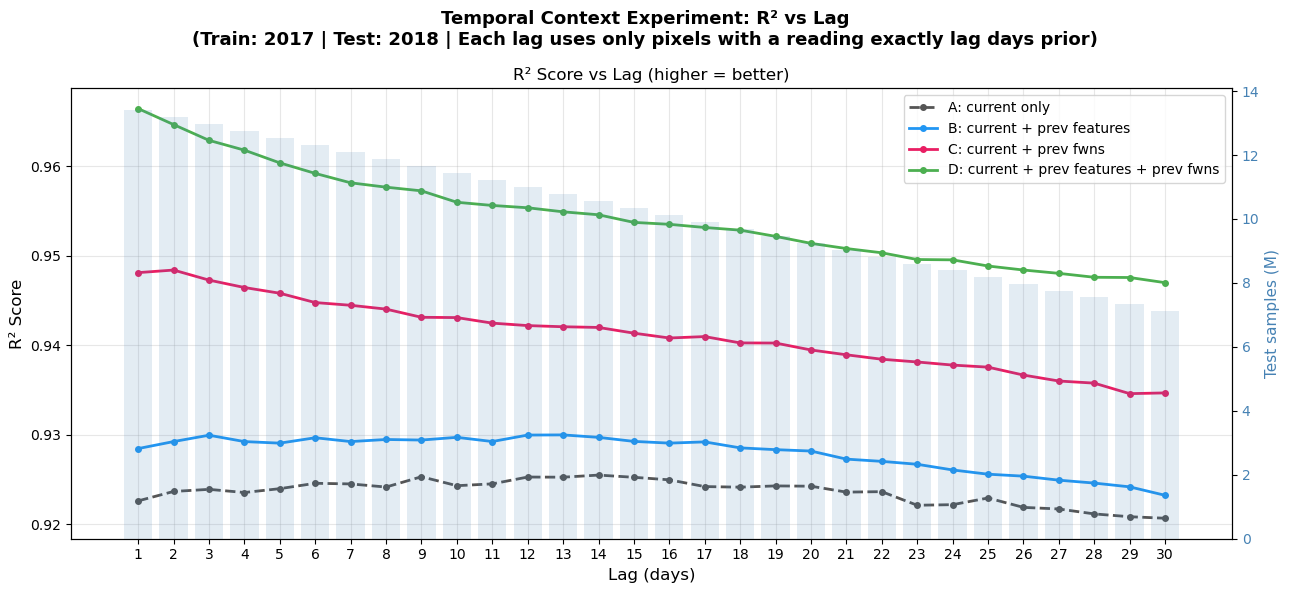

In [3]:
# Load results from CSV
results_df = pd.read_csv('results/temporal_lag_sweep.csv')

COLORS = {
    'A: current only':                       '#555555',
    'B: current + prev features':            '#2196F3',
    'C: current + prev fwns':               '#E91E63',
    'D: current + prev features + prev fwns': '#4CAF50',
}
LINESTYLES = {
    'A: current only':                       '--',
    'B: current + prev features':            '-',
    'C: current + prev fwns':               '-',
    'D: current + prev features + prev fwns': '-',
}

fig, ax = plt.subplots(figsize=(13, 6))

# Plot R² lines for all feature sets
for fs_name in FEATURE_SET_NAMES:
    sub = results_df[results_df['feature_set'] == fs_name].sort_values('lag')
    ax.plot(
        sub['lag'], sub['r2'],
        label=fs_name,
        color=COLORS[fs_name],
        linestyle=LINESTYLES[fs_name],
        linewidth=2,
        marker='o', markersize=4,
    )

ax.set_xlabel('Lag (days)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title('R² Score vs Lag (higher = better)', fontsize=12)
ax.set_xticks(LAGS)

# Secondary y-axis for sample count (transparent bars)
ax2 = ax.twinx()
sub_a = results_df[results_df['feature_set'] == FEATURE_SET_NAMES[0]].sort_values('lag')
ax2.bar(sub_a['lag'], sub_a['n_test'] / 1e6, color='steelblue', alpha=0.15, edgecolor='none', label='Test samples (M)')
ax2.set_ylabel('Test samples (M)', color='steelblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.suptitle(
    'Temporal Context Experiment: R² vs Lag\n'
    '(Train: 2017 | Test: 2018 | Each lag uses only pixels with a reading exactly lag days prior)',
    fontsize=13, fontweight='bold', y=0.98
)
plt.tight_layout()
plt.show()

## 7. Spatial Context Experiment

The temporal sweep above showed that pairing each pixel with its own observations from prior days lifts R² substantially. The complementary question is **spatial**: does aggregating same-day measurements from neighbouring pixels — adding a notion of local context to each row — also help?

This section runs a window-size sweep that mirrors the temporal lag sweep in structure: window size replaces lag, and aggregation (mean / std over the NxN neighbourhood) replaces the per-pixel shift. Train/test split, model hyperparameters, and the baseline feature list are all reused unchanged so any difference in accuracy is attributable solely to the spatial summary features.

### 7.1 Spatial feature sets

Four feature sets are evaluated at each window size:

| Set | Contents | Rationale |
|-----|----------|-----------|
| **A** | `BASELINE_FEATURES` only (no spatial context) | Reference line — identical to the temporal A set. Trained once and reused for every window size. |
| **B** | `BASELINE_FEATURES` + window **mean** of the 15 `PREV_FEATURE_COLS` | Tests whether a smoothed local average of observational and derived features adds signal. |
| **C** | `BASELINE_FEATURES` + window **std** of the 15 `PREV_FEATURE_COLS` | Tests whether local variability (texture / heterogeneity) is itself informative. |
| **D** | `BASELINE_FEATURES` + window **mean + std** | Full spatial context — combines smoothing and texture cues. |

The 15 columns aggregated are exactly the same `PREV_FEATURE_COLS` the temporal experiment lagged, so that any conclusion about "more context" can be compared directly across both axes.

**Window construction policy**

- Aggregation is done **per day**: `(year, day_of_year)` is part of the join key, so neighbours from a different day cannot leak in.
- The **center pixel is included** in the aggregation. A pixel always sees itself, so `count >= 1` for every retained row.
- **Partial windows are allowed**: at the swath edges and at coastlines, not all NxN neighbours are observed on a given day; the mean and std are computed over whatever pixels were observed. Rows with `count < 2` are dropped, since at least two values are needed to compute a meaningful std.
- **Longitude wraps modulo 1440** (the antimeridian is not a real boundary on the globe), but **latitude does not wrap** (the poles are not adjacent to each other). Pixels whose window would extend past `latitude_grid` 0 or 719 simply lose those neighbours.

In [ ]:
WINDOW_SIZES = [3, 5, 7, 9]

SPATIAL_FEATURE_SET_NAMES = [
    'A: current only',
    'B: current + window mean',
    'C: current + window std',
    'D: current + window mean + std',
]

# latitude_grid / longitude_grid in df_raw are float32 degree coordinates at
# 0.25° resolution (see GRID_RES in 1-Data_preprocessing.ipynb): pixel
# centers at lon=0.125+i*0.25 and lat=-89.875+j*0.25. build_spatial_dataset
# converts them to integer pixel indices in [0, GRID_NLAT) / [0, GRID_NLON)
# for window arithmetic.
GRID_RES  = 0.25
GRID_NLAT = 720
GRID_NLON = 1440

print(f"Window sizes: {WINDOW_SIZES}")
print(f"Feature sets: {SPATIAL_FEATURE_SET_NAMES}")


### 7.2 `build_spatial_dataset` — per-window aggregation

For a given window size *N*, `build_spatial_dataset` produces a dataset where every row carries — alongside its current-day features — the mean and standard deviation of each of the 15 `PREV_FEATURE_COLS` computed over the NxN box of same-day neighbours.

The function uses a **merge-accumulator** approach. For every offset `(dx, dy)` in the window:

1. Build a "shifted" lookup from `df_raw` whose `(latitude_grid, longitude_grid)` keys have been moved by `(-dy, -dx)` so that an inner-join on `(latitude_grid, longitude_grid, year, day_of_year)` aligns each pixel with its neighbour at offset `(dx, dy)` on the same day.
2. Apply `% 1440` to longitude (it wraps), drop rows whose shifted latitude falls outside `[0, 719]` (it does not wrap).
3. Add the neighbour's value to per-row `sum`, `sum_sq` and `count` accumulators indexed by a stable `_row_id`.

After all NxN offsets have been processed, `mean = sum / count` and `std = sqrt(max(sum_sq/count − mean², 0))` for each of the 15 columns. Rows with `count < 2` are dropped.

**Why a merge-accumulator and not a per-day dense pivot?** The dataset is sparse: ~36 k observed rows per day vs. ~1 M cells in the 720×1440 lat/lon grid. A dense pivot would waste memory on NaN-filled tiles and would require NaN-aware filtering (which `scipy.ndimage.uniform_filter` does not support natively). The merge approach instead reads each pixel's actually-observed neighbours directly from the join key, and produces results identical to a hand-rolled NaN-aware filter.

**Why incremental statistics?** Storing all NxN neighbour values per pixel (worst case 81 columns × 15 features) would multiply memory by ~80x. Maintaining only `(sum, sum_sq, count)` lets us produce mean and std at the end with a single pass over each accumulator and a constant memory footprint regardless of *N*.

**Float64 accumulators** are used to avoid catastrophic cancellation in `sum_sq − count·mean²` after summing tens of millions of squared float32 values. The final `_mean` and `_std` columns are cast back to float32 for DMatrix building.

In [ ]:
import gc

def build_spatial_dataset(df_sorted, window_size):
    """
    For a given window size N, build a dataset where each row carries:
      - its current-day features (unchanged from df_sorted)
      - <col>_mean and <col>_std for each col in PREV_FEATURE_COLS, computed
        over the NxN box of same-day neighbours (longitude wraps modulo
        GRID_NLON, latitude does not wrap, partial windows allowed).

    Implementation: merge-accumulator. df_sorted's latitude_grid/longitude_grid
    are float32 degree coordinates at 0.25° resolution; they are converted
    once to integer pixel indices (_lat_i, _lon_i) for the window arithmetic.
    For each offset (dx, dy) in the window, inner-join df_sorted with a copy
    of itself whose (_lat_i, _lon_i) keys have been shifted by (-dy, -dx). The
    center offset (0, 0) is included and contributes each pixel to its own
    statistics, so count >= 1 for every row of df_sorted. Rows with count < 2
    (i.e., no observed neighbours beyond self) are dropped.

    Statistics are accumulated in float64 (sum, sum_sq, count) to avoid
    cancellation when computing std as sqrt(sum_sq/count - mean^2).
    """
    assert window_size % 2 == 1 and window_size >= 1, \
        "window_size must be odd and >= 1"

    half = window_size // 2
    offsets = [(dx, dy) for dy in range(-half, half + 1)
                          for dx in range(-half, half + 1)]
    assert (0, 0) in offsets

    n_before = len(df_sorted)
    df = df_sorted.reset_index(drop=True).copy()
    df['_row_id'] = np.arange(len(df), dtype=np.int64)

    # Convert float-degree coordinates to integer pixel indices.
    # Pixel centers: lon = 0.125 + i*0.25, lat = -89.875 + j*0.25, so the
    # inverse is i = round((lon - 0.125) / 0.25) = round(lon/0.25 - 0.5).
    lat_idx = np.rint(df['latitude_grid'].to_numpy()  / GRID_RES - 0.5 + 90.0 / GRID_RES).astype(np.int32)
    lon_idx = np.rint(df['longitude_grid'].to_numpy() / GRID_RES - 0.5).astype(np.int32)
    assert (lat_idx >= 0).all() and (lat_idx < GRID_NLAT).all(), \
        "latitude index out of [0, GRID_NLAT)"
    assert (lon_idx >= 0).all() and (lon_idx < GRID_NLON).all(), \
        "longitude index out of [0, GRID_NLON)"
    df['_lat_i'] = lat_idx
    df['_lon_i'] = lon_idx

    # Slim lookup table: only columns the join + accumulation need.
    lookup_cols = ['_row_id', '_lat_i', '_lon_i',
                   'year', 'day_of_year'] + PREV_FEATURE_COLS
    lookup_base = df[lookup_cols]

    n = len(df)
    count_arr = np.zeros(n, dtype=np.int32)
    sum_arr   = {c: np.zeros(n, dtype=np.float64) for c in PREV_FEATURE_COLS}
    sumsq_arr = {c: np.zeros(n, dtype=np.float64) for c in PREV_FEATURE_COLS}

    print(f"  window={window_size}: aggregating over {len(offsets)} offsets "
          f"({n_before:,} rows)...", flush=True)

    for dx, dy in offsets:
        shifted = lookup_base.copy()
        # We want shifted[_lat_i, _lon_i] to align with df[_lat_i, _lon_i]
        # when the neighbour at offset (dx, dy) of df sits at
        # (df_lat_i + dy, df_lon_i + dx). So shift the lookup's keys by
        # (-dy, -dx) before merging.
        shifted['_lat_i'] = shifted['_lat_i'].to_numpy() - dy
        shifted['_lon_i'] = (shifted['_lon_i'].to_numpy() - dx) % GRID_NLON
        # Latitude does not wrap; drop OOB before the merge.
        in_range = (shifted['_lat_i'] >= 0) & (shifted['_lat_i'] < GRID_NLAT)
        shifted = shifted.loc[in_range]

        # Inner join on the four-key index. Left side keeps _row_id of the
        # current pixel; right side carries the neighbour's feature values.
        merged = df[['_row_id', '_lat_i', '_lon_i',
                     'year', 'day_of_year']].merge(
            shifted,
            on=['_lat_i', '_lon_i', 'year', 'day_of_year'],
            how='inner',
            suffixes=('', '_n'),
        )

        idx = merged['_row_id'].to_numpy()
        for col in PREV_FEATURE_COLS:
            v = merged[f'{col}_n'].to_numpy(dtype=np.float64)
            sum_arr[col][idx]   += v
            sumsq_arr[col][idx] += v * v
        count_arr[idx] += 1

        del merged, shifted, idx
        gc.collect()

    assert (count_arr >= 1).all(), "center pixel should always self-match"
    assert (count_arr <= window_size * window_size).all(), \
        "count exceeds window size — duplicate join keys?"

    # Finalize mean and std.
    keep = count_arr >= 2
    cnt_f = count_arr.astype(np.float64)
    for col in PREV_FEATURE_COLS:
        mean = sum_arr[col] / np.maximum(cnt_f, 1.0)
        var  = sumsq_arr[col] / np.maximum(cnt_f, 1.0) - mean * mean
        assert (var >= -1e-4).all(), f"unexpected negative variance for {col}"
        var = np.maximum(var, 0.0)
        df[f'{col}_mean'] = mean.astype(np.float32)
        df[f'{col}_std']  = np.sqrt(var).astype(np.float32)

    df = df.loc[keep].drop(columns=['_row_id', '_lat_i', '_lon_i']).reset_index(drop=True)

    n_after = len(df)
    print(f"  window={window_size}: kept {n_after:,} of {n_before:,} rows "
          f"({100 * n_after / n_before:.1f}%)")
    return df

print("build_spatial_dataset() defined.")


In [12]:
def get_spatial_feature_sets(mean_cols, std_cols):
    """
    Return the 4 feature sets for a spatial window experiment.
    mean_cols / std_cols: lists of '<col>_mean' / '<col>_std' column names
    present in the DataFrame produced by build_spatial_dataset.
    """
    A = BASELINE_FEATURES                              # current only
    B = BASELINE_FEATURES + mean_cols                  # current + window mean
    C = BASELINE_FEATURES + std_cols                   # current + window std
    D = BASELINE_FEATURES + mean_cols + std_cols       # current + mean + std
    return [A, B, C, D]

print("get_spatial_feature_sets() defined.")

get_spatial_feature_sets() defined.


### 7.3 Running all 16 experiments

⚠️ **Computationally expensive cell. Expected runtime: ~1–2 hours on GPU** (4 windows × {3 trainings each + 1 reused baseline} = 13 model trainings, plus per-window spatial aggregation that ranges from 9 to 81 merges over the 26.5 M-row dataset).

For each window size *N* ∈ {3, 5, 7, 9}:
1. Build the spatial dataset using `build_spatial_dataset` (mean and std columns appended).
2. Split into train (2017) and test (2018).
3. Train and evaluate feature sets B, C, D. Set A (current-day only) is invariant across windows: it is trained **once, before the loop**, and its metrics are copied to every window's A row. This both saves ~25 % of training time and guarantees a perfectly horizontal A reference line on the plot.
4. Print a progress line with per-set R² and wall-clock time.

The `spatial_results` dictionary accumulates all metrics and is the sole input to the analysis and plotting cells below.

In [13]:
import time

# spatial_results[window_size][feature_set_idx] = metrics dict
spatial_results = {}

# --- Train feature set A once: it does not depend on window size. ---
print("Training set A (baseline, no spatial context) once for reuse...")
t0 = time.time()
train_a = df_raw[df_raw['year'] == 2017]
test_a  = df_raw[df_raw['year'] == 2018]
y_train_a = train_a['fwns'].to_numpy()
y_test_a  = test_a['fwns'].to_numpy()

X_train_a = train_a[BASELINE_FEATURES].to_numpy(dtype=np.float32)
X_test_a  = test_a[BASELINE_FEATURES].to_numpy(dtype=np.float32)

dtrain_a = xgb.DMatrix(X_train_a, label=y_train_a, feature_names=BASELINE_FEATURES)
dtest_a  = xgb.DMatrix(X_test_a,  label=y_test_a,  feature_names=BASELINE_FEATURES)

metrics_A = train_and_eval(dtrain_a, dtest_a, y_test_a)
print(f"  set A: R²={metrics_A['r2']:.4f}  ({time.time() - t0:.0f}s | "
      f"train={train_a.shape[0]:,} test={test_a.shape[0]:,})")

del train_a, test_a, X_train_a, X_test_a, dtrain_a, dtest_a, y_train_a, y_test_a
gc.collect()

# --- Window sweep: train B, C, D for each window size; reuse A. ---
for window_size in WINDOW_SIZES:
    t0 = time.time()
    print(f"\n--- Window {window_size}x{window_size} ---", flush=True)

    df_win = build_spatial_dataset(df_raw, window_size)

    train = df_win[df_win['year'] == 2017]
    test  = df_win[df_win['year'] == 2018]

    mean_cols = [f'{c}_mean' for c in PREV_FEATURE_COLS]
    std_cols  = [f'{c}_std'  for c in PREV_FEATURE_COLS]
    feature_sets = get_spatial_feature_sets(mean_cols, std_cols)

    y_train = train['fwns'].to_numpy()
    y_test  = test['fwns'].to_numpy()

    # Build the widest feature set (D) once; slice columns for B and C.
    all_cols   = feature_sets[3]   # D is the superset of B and C
    X_train_np = train[all_cols].to_numpy(dtype=np.float32)
    X_test_np  = test[all_cols].to_numpy(dtype=np.float32)

    # Reuse set A's metrics, but stamp this window's train/test sample counts
    # so the CSV remains self-consistent.
    a_for_window = dict(metrics_A)
    a_for_window['n_train'] = int(train.shape[0])
    a_for_window['n_test']  = int(test.shape[0])
    win_results = [a_for_window]
    print(f"  [A:R²={a_for_window['r2']:.4f}] (reused)", end=' ', flush=True)

    # Train B, C, D.
    for fs_idx in (1, 2, 3):
        fs = feature_sets[fs_idx]
        col_idx = [all_cols.index(c) for c in fs]
        dtrain = xgb.DMatrix(X_train_np[:, col_idx], label=y_train, feature_names=fs)
        dtest  = xgb.DMatrix(X_test_np[:,  col_idx], label=y_test,  feature_names=fs)
        m = train_and_eval(dtrain, dtest, y_test)
        win_results.append(m)
        print(f"[{SPATIAL_FEATURE_SET_NAMES[fs_idx][0]}:R²={m['r2']:.4f}]",
              end=' ', flush=True)
        del dtrain, dtest

    spatial_results[window_size] = win_results
    print(f"  ({time.time() - t0:.0f}s | train={train.shape[0]:,} "
          f"test={test.shape[0]:,})")

    del df_win, train, test, X_train_np, X_test_np, y_train, y_test
    gc.collect()

print("\nAll spatial experiments complete.")

Training set A (baseline, no spatial context) once for reuse...
  set A: R²=0.9227  (39s | train=12,837,873 test=13,644,889)

--- Window 3x3 ---


AssertionError: latitude_grid out of expected range

### 7.4 Tidy results table

Flatten the `spatial_results` dictionary into a long-form DataFrame with one row per (window size, feature set) pair. The table is also persisted to `results/spatial_window_sweep.csv` so the experiment does not need to be re-run to reproduce the figures.

In [ ]:
# Build tidy spatial results DataFrame
rows = []
for window_size, win_results in spatial_results.items():
    for fs_idx, m in enumerate(win_results):
        rows.append({
            'window_size': window_size,
            'feature_set': SPATIAL_FEATURE_SET_NAMES[fs_idx],
            'r2':          m['r2'],
            'rmse':        m['rmse'],
            'mae':         m['mae'],
            'n_train':     m['n_train'],
            'n_test':      m['n_test'],
        })

spatial_results_df = pd.DataFrame(rows)

import os; os.makedirs('results', exist_ok=True)
spatial_results_df.to_csv('results/spatial_window_sweep.csv', index=False)
print(spatial_results_df.to_string(index=False))

### 7.5 Accuracy vs window size plot

R² as a function of window size for all four feature sets. A secondary y-axis overlays the test-set sample count so it is easy to judge whether metric changes are driven by model quality or by the shrinking pool of qualifying pixels.

Things to look for:

- **Gap between A and B/C/D:** how much spatial context helps relative to the no-context baseline.
- **B vs C:** whether the smoothed mean carries more or less signal than the local std (texture).
- **Trend with increasing window size:** does R² rise monotonically (more context → more help), plateau (3x3 already captures the locally relevant scale), or drop (over-smoothing washes out fine-scale information)?
- **Sample size effect:** larger windows drop more rows along the polar latitude bands and at coastlines; check whether any apparent gains coincide with the dataset shrinking.

In [ ]:
# Load spatial results from CSV
spatial_results_df = pd.read_csv('results/spatial_window_sweep.csv')

SPATIAL_COLORS = {
    'A: current only':                '#555555',
    'B: current + window mean':       '#2196F3',
    'C: current + window std':        '#E91E63',
    'D: current + window mean + std': '#4CAF50',
}
SPATIAL_LINESTYLES = {
    'A: current only':                '--',
    'B: current + window mean':       '-',
    'C: current + window std':        '-',
    'D: current + window mean + std': '-',
}

fig, ax = plt.subplots(figsize=(11, 6))

for fs_name in SPATIAL_FEATURE_SET_NAMES:
    sub = spatial_results_df[spatial_results_df['feature_set'] == fs_name].sort_values('window_size')
    ax.plot(
        sub['window_size'], sub['r2'],
        label=fs_name,
        color=SPATIAL_COLORS[fs_name],
        linestyle=SPATIAL_LINESTYLES[fs_name],
        linewidth=2,
        marker='o', markersize=6,
    )

ax.set_xlabel('Window size (NxN, in pixels)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title('R² Score vs Window Size (higher = better)', fontsize=12)
ax.set_xticks(WINDOW_SIZES)
ax.set_xticklabels([f'{n}×{n}' for n in WINDOW_SIZES])

# Secondary y-axis: test-set sample count (use set B, since B/C/D share the same row set per window)
ax2 = ax.twinx()
sub_b = spatial_results_df[spatial_results_df['feature_set'] == SPATIAL_FEATURE_SET_NAMES[1]].sort_values('window_size')
ax2.bar(sub_b['window_size'], sub_b['n_test'] / 1e6,
        width=0.6, color='steelblue', alpha=0.15, edgecolor='none',
        label='Test samples (M)')
ax2.set_ylabel('Test samples (M)', color='steelblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.suptitle(
    'Spatial Context Experiment: R² vs Window Size\n'
    '(Train: 2017 | Test: 2018 | Per-day NxN window, longitude wraps, '
    'partial windows kept if ≥ 2 observed pixels)',
    fontsize=13, fontweight='bold', y=0.98
)
plt.tight_layout()
plt.show()